# Answering Assignment Questions


## Strategic Predictions for Movie Success

**What genre of film (thriller, adventure, romantic,...) should you create to make sure you make the most money?**

**Ans:** Animation is the clear winner. It shows the highest median return (around $192.5M). It's also less crowded than heavily saturated genres like Drama or Comedy, making it a great market to target.r

**Who are the top 3 actors you should hire to make sure you make the most money?**

**Ans:** Based on my data analysis casting Rupert Grint, Daniel Radcliffe, and Emma Watson. The real, practical takeaway here is that casting leads with a built-in, dedicated fandom (or tying them to a massive IP) is one of the safest bets for high box office returns.

**Which film director and film producer should you hire to make sure you make the most money?**

**Ans:** Joss Whedon tops the list for directors (with a median revenue of $1.4B), and Christopher Meledandri is the top producer ($923M). The data shows that top producers tend to be much more consistent for hits across their careers compared to directors, whose box office numbers can vary wildly from film to film.

**How should you spend to produce the movie to optimize ROI?**

**Ans:** It depends on how you measure success. Analysis shows that for the best risk-adjusted returns, a budget between $40-100M is the sweet spot. If you just want the biggest possible absolute total gross, you have to spend big (over $100-200M). That said, micro-budgets (under $5M) actually give the highest percentage ROI (median 3.78x) simply because they are so cheap to make—they just won't pull in blockbuster-level cash.

**Any other impactful parameters you want to include**

**Ans:** Budget and pre-release popularity scores are the biggest predictors of a movie's final scale. Beyond that, timing is everything like releasing during the summer or the holiday season gives a big bump. Runtimes hitting that 120-150 minute sweet spot, having a large crew, and filming in English for global distribution also consistently drive up revenue.

---

## My Process Execution

**Data Collection: We have provided two baseline datasets on IMDB Top 5000 films to be downloaded. If you wish to enrich this data by bringing in external sources, you are encouraged to do so. If additional data will be brought in, what will that be, in which format, from which source, ... ?**

**Ans:** I pulled in external data using live REST API calls to The Movie Database (TMDB) API (completing the BONUS assignment). I mapped everything using the original `movie_id`. This was super helpful because it let me pull current metrics—like updated budgets, global box office numbers, and social popularity scores which fixed a lot of the missing or zeroed-out financial data in the original baseline CSVs.

**Data Mining: What exploration can you perform? What insights do you find from the data you extracted?**

**Ans:** When digging into the data, the first thing I noticed was that box office revenue is heavily right-skewed a few massive blockbusters warp the averages, so I relied on median numbers for a more accurate picture. A few key takeaways:

* **Genre Opportunity:** Animation has a great median return (~$192.5M) without being nearly as flooded as the Drama or Comedy categories.
* **Timing:** People really do go to the movies mostly at two times of the year: early summer (May-June) and the holidays (Nov-Dec).
* **Talent:** A great producer seems to offer a safer financial baseline across a portfolio of movies than a great director, who tends to be more hit-or-miss.
* **ROI vs. Revenue:** It's a U-shaped curve. You get massive percentage ROIs on cheap indie films under $5M, but if you want huge absolute dollar amounts, you're forced to risk $100M+ budgets.

**Data Transformation: What kind of transformation, cleaning, normalization, … , you did on the dataset to make it usable?**

**Ans:** Here is how I cleaned and prepped the data pipeline:

* **Cleaning:** I dropped unreleased movies, rows with missing runtimes, and anything that had $0 for the budget or revenue (since those were clearly placeholders).
* **Parsing & Encoding:** I had to parse out some messy nested JSON strings to get the top 3 actors, directors, producers, and genres. I one-hot encoded the 19 genres and the 12 calendar release months.
* **Target Encoding:** I calculated historical median revenues for the cast and crew, but I was careful to only do this on the training data so I didn't leak future information into the testing set.
* **Scaling:** Because the revenue and budget numbers vary exponentially, I applied a log transformation to both to smooth things out. I skipped standardizing the features since tree-based models like XGBoost don't really care about scale anyway.

**Data Science: How do you deal with the predictions? What kind of algorithms are you going to use? Which one did you choose and why? What challenges did you face and how did you overcome them?**

**Ans:** I treated this as a regression problem, predicting the log of the revenue and then converting it back to real dollars at the end via an exponential inverse.

I went with **XGBoost (eXtreme Gradient Boosting)** as my main algorithm. It's really good at handling non-linear relationships, it isn't completely thrown off by extreme box office outliers, and it handles a mix of continuous and binary data without needing much hand-holding.

My biggest challenge was overfitting. Because the dataset isn't huge and I had high-cardinality encoded features for the talent, the model was just memorizing the data. I fixed this by keeping the trees relatively shallow (`max_depth=6`), adding strong L1 and L2 regularization, and using 5-fold cross-validation with early stopping. This kept the model honest and generalized well on the unseen test set.

**Technical Optimizations:**

**Ans:** I also added a couple of improvements to the pipeline to make it run more efficiently:

* **API Data Caching:** I wrote a quick script to save the live TMDB API responses locally into a CSV (`tmdb_5000_enriched.csv`). This way, I didn't have to hit the API every single time I restarted the notebook, which saved a ton of time and prevented network timeouts.
* **Model Serialization:** Once the XGBoost model was dialed in, I exported it as a `.pkl` file (`movie_revenue_model.pkl`). Now it can be loaded up instantly to make predictions on new movie pitches without having to retrain the whole algorithm from scratch.

# 1. Imports

In [ ]:
!pip install -r requirements.txt

In [47]:
import pandas as pd
import numpy as np
import json
import math
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from dotenv import load_dotenv
load_dotenv()
import requests
from tqdm.auto import tqdm
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MultiLabelBinarizer

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

print(" All libraries loaded successfully.")

 All libraries loaded successfully.


# 2. External API Integration (BONUS)

In [48]:
#  Load and Enrich the raw datasets (Bonus) 
movies = pd.read_csv('TMDB_5000_data/tmdb_5000_movies.csv')
credits = pd.read_csv('TMDB_5000_data/tmdb_5000_credits.csv')
df = movies.merge(credits, left_on='id', right_on='movie_id', suffixes=('', '_credits'))

API_KEY = os.getenv("TMDB_API_KEY")

def fetch_tmdb_data(movie_id):
    '''Fetches real-time social metrics and updated financials from TMDB.'''
    if not API_KEY:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}&language=en-US"
    try:
        response = requests.get(url, timeout=3)
        if response.status_code == 200:
            data = response.json()
            return pd.Series([
                data.get('popularity'),
                data.get('vote_average'),
                data.get('vote_count'), 
                data.get('budget'), 
                data.get('revenue')
            ])
    except:
        pass
    return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])

cached_file = 'tmdb_5000_enriched.csv'

if os.path.exists(cached_file):
    print("--- Loading cached data ---")
    print(f"Found '{cached_file}'. Skipping API calls.")
    df = pd.read_csv(cached_file)
else:
    print("--- Fetching live API data ---")
    
    # We only apply API where we intend to overwrite later
    if API_KEY:
        tqdm.pandas(desc="TMDB API Progress")
        df[['live_pop', 'live_vote_avg', 'live_vote_count', 'updated_budget', 'updated_revenue']] = df['id'].progress_apply(fetch_tmdb_data)
    else:
        print("TMDB_API_KEY not set. Using original CSV values across the board.")
        for col in ['live_pop', 'live_vote_avg', 'live_vote_count', 'updated_budget', 'updated_revenue']:
            df[col] = np.nan

    df['final_budget'] = df['budget']
    df['final_revenue'] = df['revenue']
    df['final_popularity'] = df['popularity']
    df['final_vote_average'] = df['vote_average']
    df['final_vote_count'] = df['vote_count']

    if API_KEY:
        # Flag rows where the live API returned newer numbers than the CSV
        stale_budgets = (df['updated_budget'].notna()) & (df['updated_budget'] != df['budget']) & (df['updated_budget'] > 0)
        stale_revenue = (df['updated_revenue'].notna()) & (df['updated_revenue'] != df['revenue']) & (df['updated_revenue'] > 0)
        stale_pop = (df['live_pop'].notna()) & (df['live_pop'] != df['popularity'])
        vote_avg_diffs = (df['live_vote_avg'].notna()) & (df['live_vote_avg'] != df['vote_average'])
        vote_count_diffs = (df['live_vote_count'].notna()) & (df['live_vote_count'] != df['vote_count'])

        print(f"Outdated Budgets corrected by API: {stale_budgets.sum()}")
        print(f"Outdated Revenues corrected by API: {stale_revenue.sum()}")
        print(f"Popularity metrics updated by API: {stale_pop.sum()}")
        print(f"Vote average metrics updated by API: {vote_avg_diffs.sum()}")
        print(f"Vote count metrics updated by API: {vote_count_diffs.sum()}")
        df.loc[stale_budgets, 'final_budget'] = df.loc[stale_budgets, 'updated_budget']
        df.loc[stale_revenue, 'final_revenue'] = df.loc[stale_revenue, 'updated_revenue']
        df.loc[stale_pop, 'final_popularity'] = df.loc[stale_pop, 'live_pop']
        df.loc[vote_avg_diffs, 'final_vote_average'] = df.loc[vote_avg_diffs, 'live_vote_avg']
        df.loc[vote_count_diffs, 'final_vote_count'] = df.loc[vote_count_diffs, 'live_vote_count']

    df.to_csv(cached_file, index=False)
    print(f"Saved enriched data to '{cached_file}'.")

print("--- Raw data inspection ---")
print(f"Total Combined Rows: {df.shape[0]}")
print(f"Movies with $0 Final Budget: {(df['final_budget'] == 0).sum()}")
print(f"Movies with $0 Final Revenue: {(df['final_revenue'] == 0).sum()}")
df.head(10)

--- Loading cached data ---
Found 'tmdb_5000_enriched.csv'. Skipping API calls.
--- Raw data inspection ---
Total Combined Rows: 4803
Movies with $0 Final Budget: 1037
Movies with $0 Final Revenue: 1427


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,...,vote_count,movie_id,title_credits,cast,crew,live_pop,live_vote_avg,live_vote_count,updated_budget,updated_revenue,final_budget,final_revenue,final_popularity,final_vote_average,final_vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.44,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",...,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",NaN,NaN,NaN,NaN,NaN,237000000,2787965087,150.44,7.20,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.08,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",...,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",NaN,NaN,NaN,NaN,NaN,300000000,961000000,139.08,6.90,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.38,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.00,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",...,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",NaN,NaN,NaN,NaN,NaN,245000000,880674609,107.38,6.30,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.31,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",...,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",NaN,NaN,NaN,NaN,NaN,250000000,1084939099,112.31,7.60,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.93,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.00,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",...,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",NaN,NaN,NaN,NaN,NaN,260000000,284139100,43.93,6.10,2124
5,258000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",http://www.sonypictures.com/movies/spider-man3/,559,"[{""id"": 851, ""name"": ""dual identity""}, {""id"": ...",en,Spider-Man 3,The seemingly invincible Spider-Man goes up ag...,115.70,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","

# 3. EDA / Data Mining

## 3.1 Evaluate numeric and categorical columns

In [49]:
# Check the structure and data types of the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [50]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Extract Categorical Columns (object/string, category, boolean)
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['budget', 'id', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count', 'movie_id', 'live_pop', 'live_vote_avg', 'live_vote_count', 'updated_budget', 'updated_revenue', 'final_budget', 'final_revenue', 'final_popularity', 'final_vote_average', 'final_vote_count']
Categorical Columns: ['genres', 'homepage', 'keywords', 'original_language', 'original_title', 'overview', 'production_companies', 'production_countries', 'release_date', 'spoken_languages', 'status', 'tagline', 'title', 'title_credits', 'cast', 'crew']


In [51]:
# Basic statistics for final numeric columns
df[['final_budget', 'final_revenue', 'final_popularity', 'runtime', 'final_vote_average', 'final_vote_count']].describe()

,final_budget,final_revenue,final_popularity,runtime,final_vote_average,final_vote_count
count,"4,803.00","4,803.00","4,803.00","4,801.00","4,803.00","4,803.00"
mean,"29,045,039.88","82,260,638.65",21.49,106.88,6.09,690.22
std,"40,722,391.26","162,857,100.94",31.82,22.61,1.19,"1,234.59"
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,"790,000.00",0.00,4.67,94.00,5.60,54.00
50%,"15,000,000.00","19,170,001.00",12.92,103.00,6.20,235.00
75%,"40,000,000.00","92,917,187.00",28.31,118.00,6.80,737.00
max,"380,000,000.00","2,787,965,087.00",875.58,338.00,10.00,"13,752.00"


## 3.2 Handle missing values

In [52]:
# Missing and zero-value check
def summarize_missing(df):
    summary = []
    total_rows = len(df)
    
    for col in df.columns:
        # Count nulls
        null_count = df[col].isna().sum()
        
        # Count zeros (numeric only)
        if pd.api.types.is_numeric_dtype(df[col]):
            zero_count = (df[col] == 0).sum()
        else:
            zero_count = 0  # Skip text/object columns for zero check
            
        # Keep only columns with something to report
        if null_count > 0 or zero_count > 0:
            summary.append({
                'Column': col,
                'Null Count': null_count,
                'Null %': f"{(null_count / total_rows) * 100:.2f}%",
                'Zero Count': zero_count,
                'Zero %': f"{(zero_count / total_rows) * 100:.2f}%"
            })
            
    # Wrap in a DataFrame for display
    summary_df = pd.DataFrame(summary).sort_values(by='Zero Count', ascending=False).reset_index(drop=True)
    return summary_df

print("--- Missing and Zero Values Summary ---")
null_summary = summarize_missing(df)
display(null_summary)

--- Missing and Zero Values Summary ---


,Column,Null Count,Null %,Zero Count,Zero %
0,final_revenue,0,0.00%,1427,29.71%
1,revenue,0,0.00%,1427,29.71%
2,budget,0,0.00%,1037,21.59%
3,final_budget,0,0.00%,1037,21.59%
4,final_vote_average,0,0.00%,63,1.31%
5,vote_average,0,0.00%,63,1.31%
6,vote_count,0,0.00%,62,1.29%
7,final_vote_count,0,0.00%,62,1.29%
8,runtime,2,0.04%,35,0.73%
9,final_popularity,0,0.00%,1,0.02%


In [53]:
# How many rows have zero budget or zero revenue? 
zero_budget  = (df['budget'] == 0).sum()
zero_revenue = (df['revenue'] == 0).sum()
both_zero    = ((df['budget'] == 0) & (df['revenue'] == 0)).sum()


print(f"Zero budget:   {zero_budget:,} ({zero_budget/len(df)*100:.1f}%)")
print(f"Zero revenue:  {zero_revenue:,} ({zero_revenue/len(df)*100:.1f}%)")
print(f"Both zero:     {both_zero:,}")
print(f"\nThese zeros are missing values, not real $0 movies.")
print(f"We will filter these out before modeling.")

Zero budget:   1,037 (21.6%)
Zero revenue:  1,427 (29.7%)
Both zero:     890

These zeros are missing values, not real $0 movies.
We will filter these out before modeling.


## 3.3 Analyze numeric distributions


Numeric distributions


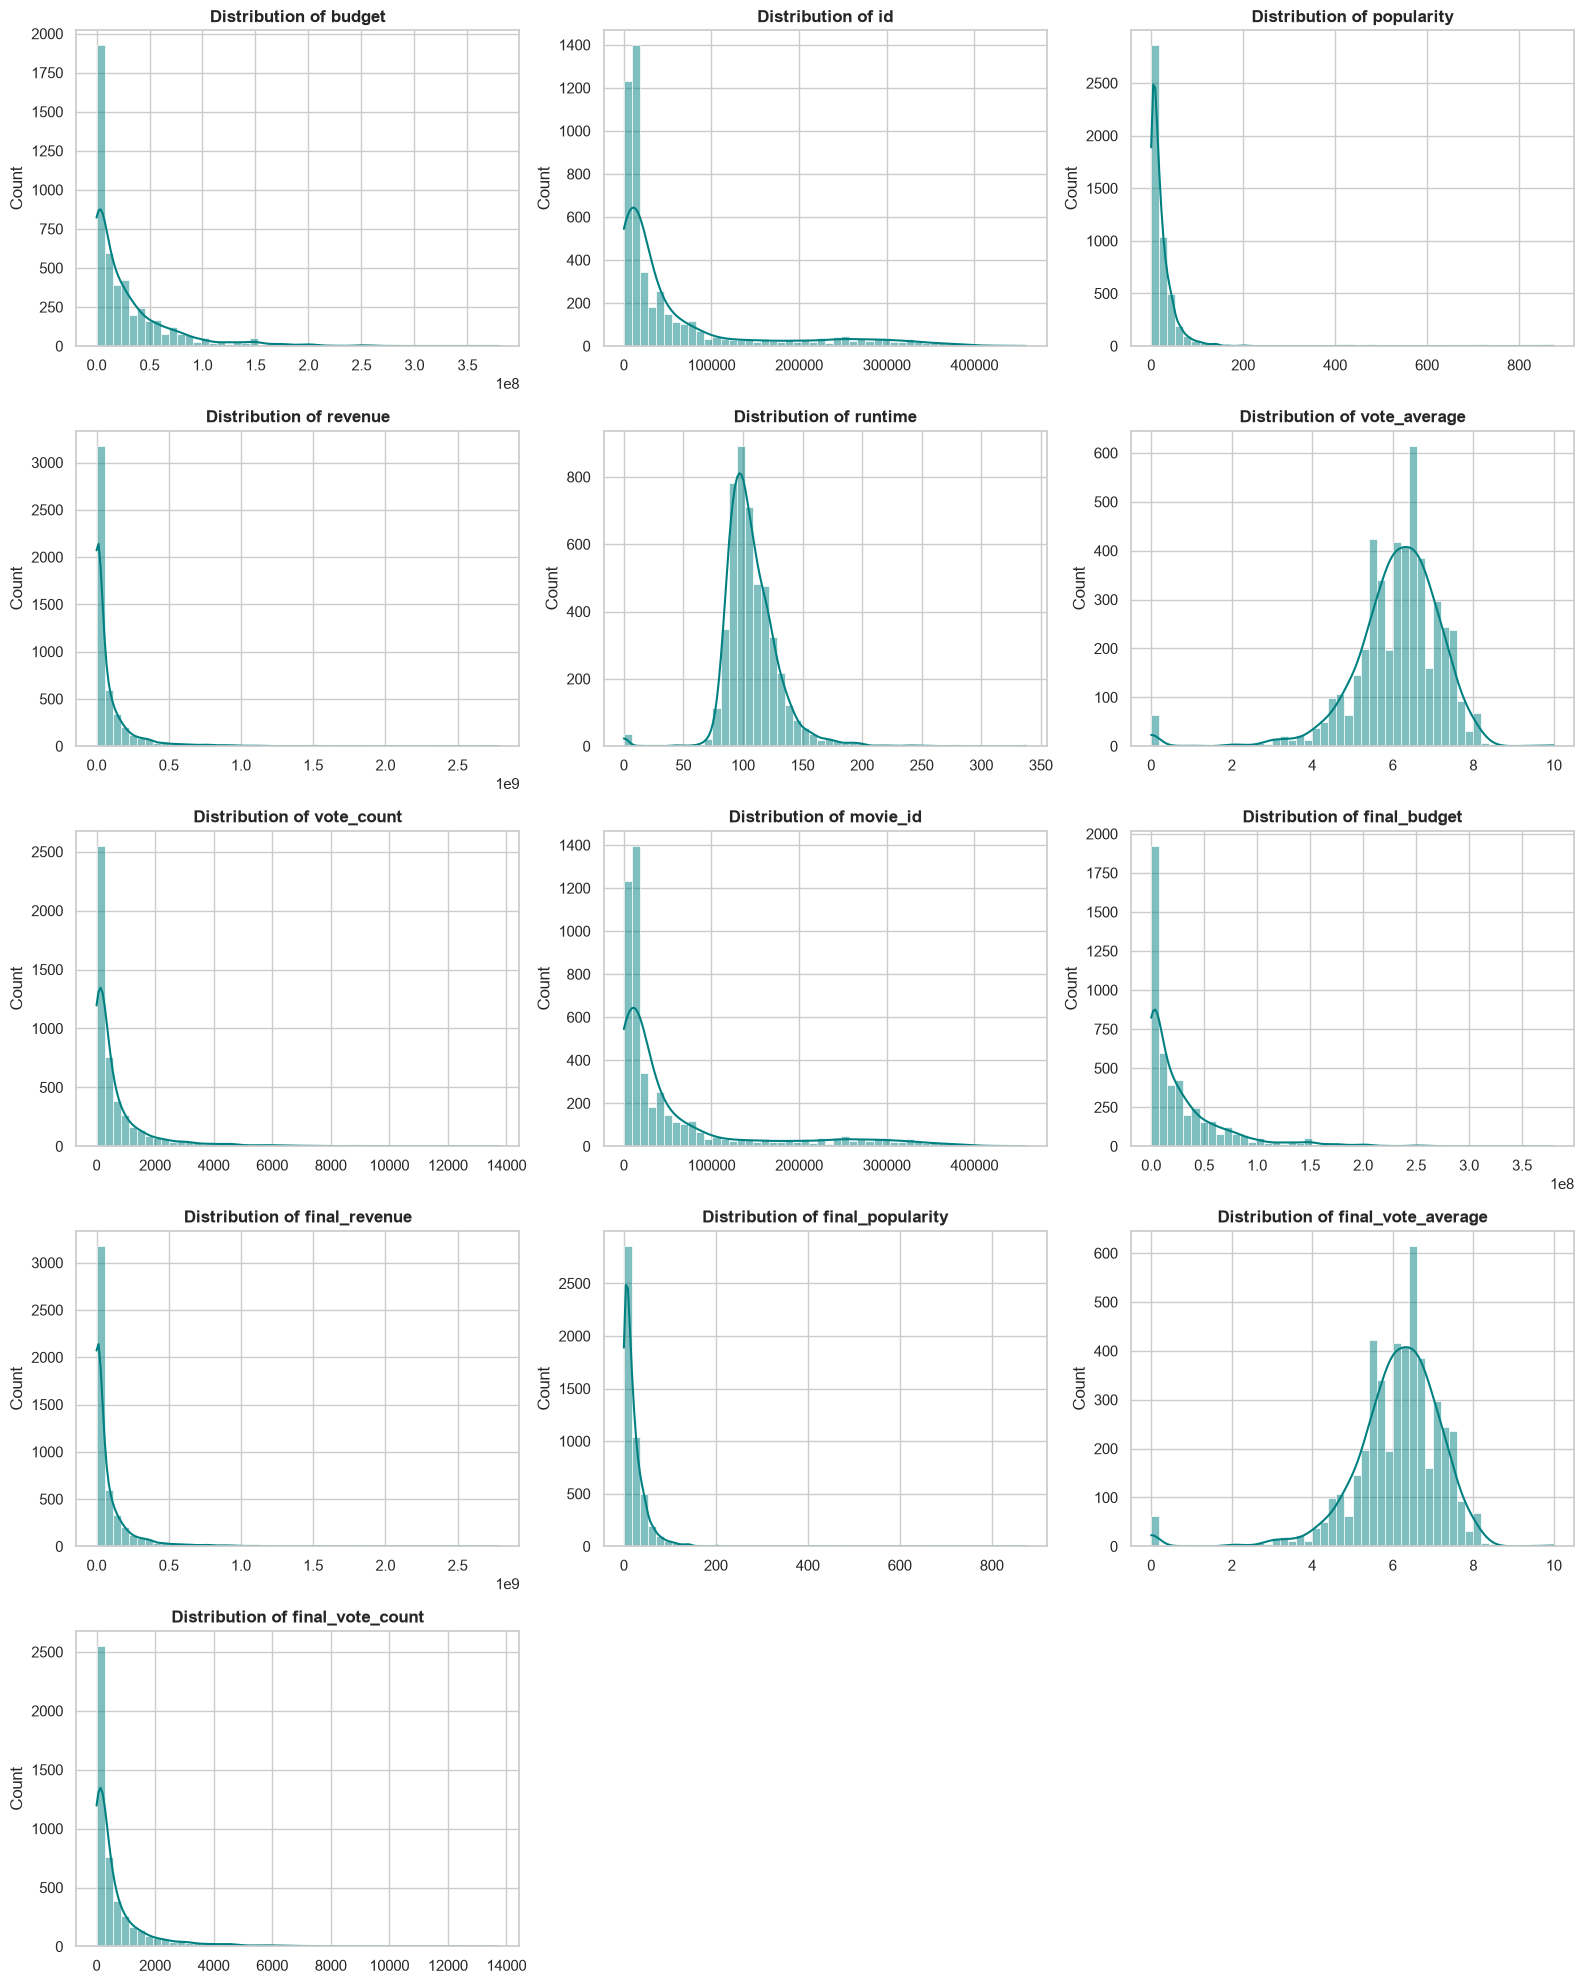

In [54]:
print("Numeric distributions")

# Drop fully-empty columns
valid_cols = [col for col in numeric_cols if not df[col].dropna().empty]

# Build subplot grid
cols = 3
rows = math.ceil(len(valid_cols) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

# Plot each column
for i, col in enumerate(valid_cols):
    clean_series = df[col].dropna()
    
    sns.histplot(clean_series, bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# Hide unused subplots
for j in range(len(valid_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('valid_numeric_distributions.png', bbox_inches='tight')
plt.show()

Financial and popularity metrics show a heavy right-skewed tail.


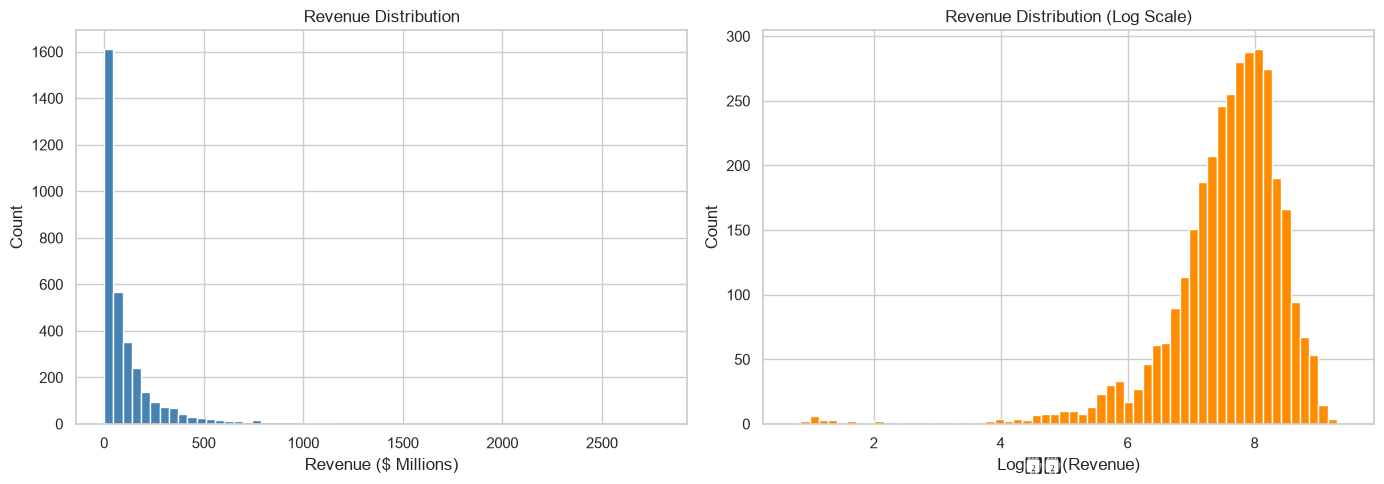

Median revenue: $51,751,835
Mean revenue:   $117,031,353


In [55]:
valid_rev = df[df['revenue'] > 0]['revenue']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(valid_rev / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Revenue ($ Millions)')
axes[0].set_ylabel('Count')
axes[0].set_title('Revenue Distribution')

axes[1].hist(np.log10(valid_rev), bins=60, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Log₁₀(Revenue)')
axes[1].set_ylabel('Count')
axes[1].set_title('Revenue Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('revenue_distribution.png', bbox_inches='tight')
plt.show()

print(f"Median revenue: ${valid_rev.median():,.0f}")
print(f"Mean revenue:   ${valid_rev.mean():,.0f}")

Revenue is highly right-skewed. Log-transforming it will stabilize variance for modeling.


## 3.4 Parse nested JSON structures
Several columns in the dataset contain JSON-encoded lists. We need to parse these to extract meaningful features.

In [56]:
def extract_json_lists(series):
    """Parse a JSON-encoded string column into Python lists of dicts."""
    def _safe_parse(x):
        if pd.isna(x):
            return []
        try:
            return json.loads(x)
        except (json.JSONDecodeError, TypeError):
            return []
    return series.apply(_safe_parse)

# Parse JSON columns
df['genres_parsed']     = extract_json_lists(df['genres'])
df['keywords_parsed']   = extract_json_lists(df['keywords'])
df['cast_parsed']       = extract_json_lists(df['cast'])
df['crew_parsed']       = extract_json_lists(df['crew'])
df['prod_co_parsed']    = extract_json_lists(df['production_companies'])
df['prod_ctry_parsed']  = extract_json_lists(df['production_countries'])

print(" JSON columns parsed successfully.")

 JSON columns parsed successfully.


In [57]:
# Build features from parsed JSON
# Genre names
df['genre_names'] = df['genres_parsed'].apply(lambda x: [g['name'] for g in x])

# Top 3 cast members (by billing order)
df['top3_cast'] = df['cast_parsed'].apply(lambda x: [c['name'] for c in sorted(x, key=lambda c: c.get('order', 999))[:3]])

# Director
df['director'] = df['crew_parsed'].apply(
    lambda crew: next((c['name'] for c in crew if c.get('job') == 'Director'), None))

# Producer (the first listed)
df['producer'] = df['crew_parsed'].apply(
    lambda crew: next((c['name'] for c in crew if c.get('job') == 'Producer'), None))

# Lead actor
df['lead_actor'] = df['cast_parsed'].apply(
    lambda cast: cast[0]['name'] if len(cast) > 0 else None)

# Production company (primary)
df['primary_prod_co'] = df['prod_co_parsed'].apply(
    lambda x: x[0]['name'] if len(x) > 0 else None)

# Number of genres, cast size
df['num_genres'] = df['genre_names'].apply(len)
df['cast_size']  = df['cast_parsed'].apply(len)
df['crew_size']  = df['crew_parsed'].apply(len)

print("Extracted: genre_names, top3_cast, director, producer, lead_actor, primary_prod_co from the JSON columns.")
df[['title', 'genre_names', 'director', 'producer', 'lead_actor']].head()

Extracted: genre_names, top3_cast, director, producer, lead_actor, primary_prod_co from the JSON columns.


,title,genre_names,director,producer,lead_actor
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]",James Cameron,James Cameron,Sam Worthington
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",Gore Verbinski,Jerry Bruckheimer,Johnny Depp
2,Spectre,"[Action, Adventure, Crime]",Sam Mendes,Barbara Broccoli,Daniel Craig
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",Christopher Nolan,Charles Roven,Christian Bale
4,John Carter,"[Action, Adventure, Science Fiction]",Andrew Stanton,Colin Wilson,Taylor Kitsch


## 3.5 Analyze genre performance

In [58]:
genre_df = df[df['revenue'] > 0].copy()

# Exploring genres so each genre gets its own row
genres_flat = genre_df.explode('genre_names')
genres_flat = genres_flat[genres_flat['genre_names'].notna()]

genre_stats = genres_flat.groupby('genre_names').agg(
    count=('revenue', 'size'),
    mean_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    total_revenue=('revenue', 'sum')
).sort_values('median_revenue', ascending=False)

genre_stats['mean_revenue_M'] = genre_stats['mean_revenue'] / 1e6
genre_stats['median_revenue_M'] = genre_stats['median_revenue'] / 1e6

print("Revenue by Genre (movies with revenue > 0):\n")
print(genre_stats[['count', 'mean_revenue_M', 'median_revenue_M']].to_string())

Revenue by Genre (movies with revenue > 0):

                 count  mean_revenue_M  median_revenue_M
genre_names                                             
Animation          191          276.50            192.45
Adventure          675          244.21            127.60
Fantasy            351          233.57            122.49
Family             382          218.02            119.90
Action             940          173.36             85.49
Science Fiction    439          185.80             78.00
Mystery            268          101.67             58.69
Thriller           959          107.66             57.10
Comedy            1174          104.57             52.50
War                122           99.33             50.56
History            150           75.55             47.16
Crime              537           85.74             44.86
Horror             344           65.70             40.46
Romance            604           88.81             38.26
Drama             1527           78.40     

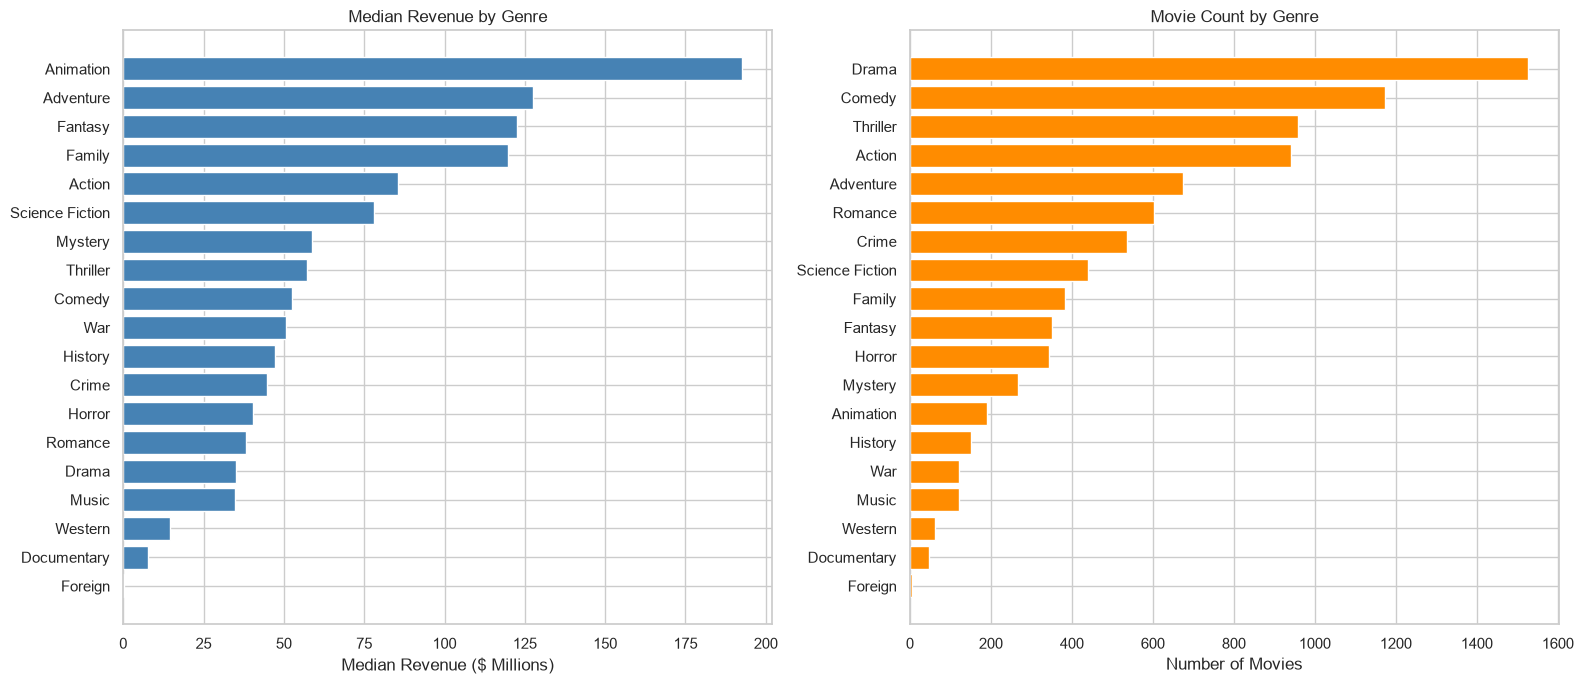

In [59]:
#Visualizing genre revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Median revenue by genre
top_genres = genre_stats.sort_values('median_revenue', ascending=True)
axes[0].barh(top_genres.index, top_genres['median_revenue_M'], color='steelblue')
axes[0].set_xlabel('Median Revenue ($ Millions)')
axes[0].set_title('Median Revenue by Genre')

# Movie count by genre
genre_counts = genre_stats.sort_values('count', ascending=True)
axes[1].barh(genre_counts.index, genre_counts['count'], color='darkorange')
axes[1].set_xlabel('Number of Movies')
axes[1].set_title('Movie Count by Genre')

plt.tight_layout()
plt.savefig('genre_revenue.png', bbox_inches='tight')
plt.show()

Animation yields the highest median return (~$200M) despite low production volume. Drama and comedy features are numerous but earn much lower median revenues.


## 3.6 Analyze actor revenue

In [60]:
# Revenue by lead actor (top 20)
actor_df = df[(df['revenue'] > 0) & (df['lead_actor'].notna())].copy()

actor_stats = actor_df.groupby('lead_actor').agg(
    count=('revenue', 'size'),
    mean_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    total_revenue=('revenue', 'sum')
)

# Require at least 5 lead roles
top_actors_stats = actor_stats[actor_stats['count'] >= 5].sort_values('median_revenue', ascending=False)

print("Top 20 Lead Actors by Median Revenue (min 5 movies):\n")
top20_actors = top_actors_stats.head(20).copy()
top20_actors['mean_revenue_M'] = top20_actors['mean_revenue'] / 1e6
top20_actors['median_revenue_M'] = top20_actors['median_revenue'] / 1e6
top20_actors['total_revenue_M'] = top20_actors['total_revenue'] / 1e6
print(top20_actors[['count', 'mean_revenue_M', 'median_revenue_M', 'total_revenue_M']].to_string())

Top 20 Lead Actors by Median Revenue (min 5 movies):

                   count  mean_revenue_M  median_revenue_M  total_revenue_M
lead_actor                                                                 
Daniel Radcliffe       7          791.26            895.92         5,538.79
Tobey Maguire          5          508.06            783.77         2,540.30
Jennifer Lawrence      7          443.35            653.43         3,103.42
Robert Downey Jr.     11          588.14            524.03         6,469.50
Daniel Craig           8          432.40            409.35         3,459.17
Kristen Stewart        7          434.75            396.60         3,043.28
Hugh Jackman          10          304.84            336.17         3,048.37
Will Smith            16          366.21            327.16         5,859.43
Chris Pine             6          267.68            325.21         1,606.11
Mike Myers             9          421.62            310.94         3,794.60
Tom Cruise            23          

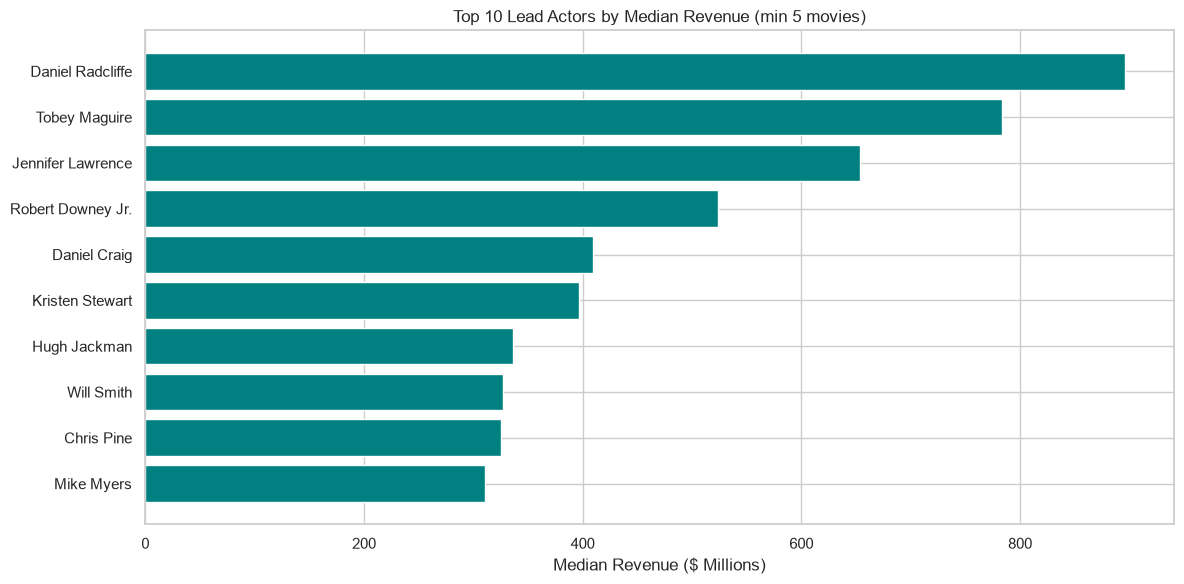

In [61]:
# Visualize top actors
top10 = top_actors_stats.head(10).sort_values('median_revenue')

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top10.index, top10['median_revenue'] / 1e6, color='teal')
ax.set_xlabel('Median Revenue ($ Millions)')
ax.set_title('Top 10 Lead Actors by Median Revenue (min 5 movies)')
plt.tight_layout()
plt.savefig('top_actors.png', bbox_inches='tight')
plt.show()

Daniel Radcliffe leads with ~$900M in median revenue. Actors with established audiences serve as a strong baseline predictor for overall revenue.


## 3.7 Evaluate cast sizes

In [62]:
# Revenue across the top-3 cast
cast_df = df[(df['revenue'] > 0)].copy()

cast_exploded = cast_df.explode('top3_cast')
cast_exploded = cast_exploded[cast_exploded['top3_cast'].notna()]

all_actor_stats = cast_exploded.groupby('top3_cast').agg(
    appearances=('revenue', 'size'),
    mean_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    total_revenue=('revenue', 'sum')
)

# Minimum 5 appearances
frequent_actors = all_actor_stats[all_actor_stats['appearances'] >= 5].sort_values('median_revenue', ascending=False)

print("Top 15 Actors by Median Revenue (top-3 billing, min 5 appearances):\n")
top15_all = frequent_actors.head(15).copy()
top15_all['mean_revenue_M'] = top15_all['mean_revenue'] / 1e6
top15_all['median_revenue_M'] = top15_all['median_revenue'] / 1e6
print(top15_all[['appearances', 'mean_revenue_M', 'median_revenue_M']].to_string())

Top 15 Actors by Median Revenue (top-3 billing, min 5 appearances):

                  appearances  mean_revenue_M  median_revenue_M
top3_cast                                                      
Rupert Grint                7          773.50            895.92
Daniel Radcliffe            8          696.63            886.30
Emma Watson                10          587.56            833.25
Ian McKellen               12          654.52            819.59
Robert Pattinson            5          548.82            698.49
Taylor Lautner              5          477.77            698.49
Liam Hemsworth              5          666.77            691.21
Ray Romano                  5          564.43            660.94
Orlando Bloom               7          510.72            497.41
Chris Pratt                 5          572.22            469.16
Denis Leary                 5          421.97            383.26
Megan Fox                   6          385.15            361.41
Will Smith                 20      

## 3.8 Analyze director and producer track records

In [63]:
# Director analysis
dir_df = df[(df['revenue'] > 0) & (df['director'].notna())].copy()

dir_stats = dir_df.groupby('director').agg(
    count=('revenue', 'size'),
    mean_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    total_revenue=('revenue', 'sum')
)
top_directors_stats = dir_stats[dir_stats['count'] >= 3].sort_values('median_revenue', ascending=False)

print("Top 15 Directors by Median Revenue (min 3 movies):\n")
top15_dirs = top_directors_stats.head(15).copy()
top15_dirs['mean_revenue_M'] = top15_dirs['mean_revenue'] / 1e6
top15_dirs['median_revenue_M'] = top15_dirs['median_revenue'] / 1e6
print(top15_dirs[['count', 'mean_revenue_M', 'median_revenue_M']].to_string())

Top 15 Directors by Median Revenue (min 3 movies):

                   count  mean_revenue_M  median_revenue_M
director                                                  
Joss Whedon            3          987.94          1,405.40
David Yates            3          742.97            933.96
Peter Jackson          9          722.07            926.29
George Lucas           5          667.82            775.40
Pete Docter            3          718.51            735.10
Anthony Russo          3          666.17            714.77
Marc Webb              3          506.22            705.72
Francis Lawrence       5          590.49            653.43
Carlos Saldanha        4          633.11            580.56
Christopher Nolan      8          528.44            524.67
Chris Sanders          3          408.61            494.88
Andrew Adamson         5          521.37            484.41
John Lasseter          4          473.19            479.68
Eric Darnell           4          420.47            453.12
Kenn

In [64]:
# ── Producer analysis ──────────────────────────────────────────────
prod_df = df[(df['revenue'] > 0) & (df['producer'].notna())].copy()

prod_stats = prod_df.groupby('producer').agg(
    count=('revenue', 'size'),
    mean_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'),
    total_revenue=('revenue', 'sum')
)
top_producers_stats = prod_stats[prod_stats['count'] >= 3].sort_values('median_revenue', ascending=False)

print("Top 15 Producers by Median Revenue (min 3 movies, train set only):\n")
top15_prods = top_producers_stats.head(15).copy()
top15_prods['mean_revenue_M'] = top15_prods['mean_revenue'] / 1e6
top15_prods['median_revenue_M'] = top15_prods['median_revenue'] / 1e6
print(top15_prods[['count', 'mean_revenue_M', 'median_revenue_M']].to_string())

Top 15 Producers by Median Revenue (min 3 movies, train set only):

                        count  mean_revenue_M  median_revenue_M
producer                                                       
Christopher Meledandri      4          886.74            923.36
David Heyman                8          702.16            886.30
Barrie M. Osborne           5          634.66            871.37
Rick McCallum               3          608.23            850.00
Aron Warner                 3          630.18            798.96
Don Murphy                  6          676.82            773.00
Peter Jackson               6          631.64            753.01
Kevin Feige                11          853.59            714.77
Christopher Nolan           3          536.78            675.12
Jon Kilik                   7          427.68            653.43
Gary Kurtz                  3          484.60            538.40
Lori Forte                  4          549.83            522.10
James Cameron               5       

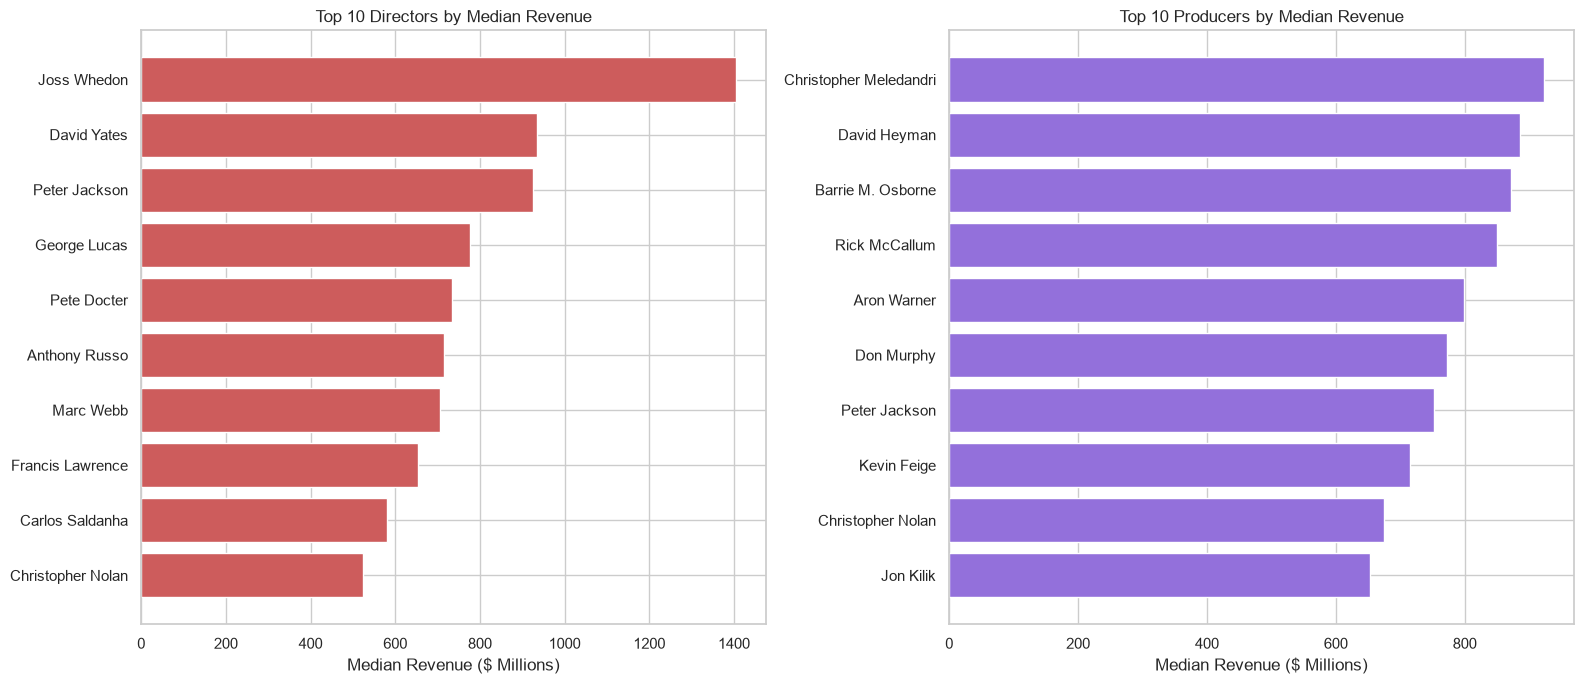

In [65]:
# ── Visualize directors and producers side by side ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

top10_dirs = top_directors_stats.head(10).sort_values('median_revenue')
axes[0].barh(top10_dirs.index, top10_dirs['median_revenue'] / 1e6, color='indianred')
axes[0].set_xlabel('Median Revenue ($ Millions)')
axes[0].set_title('Top 10 Directors by Median Revenue')

top10_prods = top_producers_stats.head(10).sort_values('median_revenue')
axes[1].barh(top10_prods.index, top10_prods['median_revenue'] / 1e6, color='mediumpurple')
axes[1].set_xlabel('Median Revenue ($ Millions)')
axes[1].set_title('Top 10 Producers by Median Revenue')

plt.tight_layout()
plt.savefig('directors_producers.png', bbox_inches='tight')
plt.show()

Director performance is volatile with steep drop-offs after massive hits. Producers show more consistent financial floors.


## 3.9 Assess budget vs. ROI

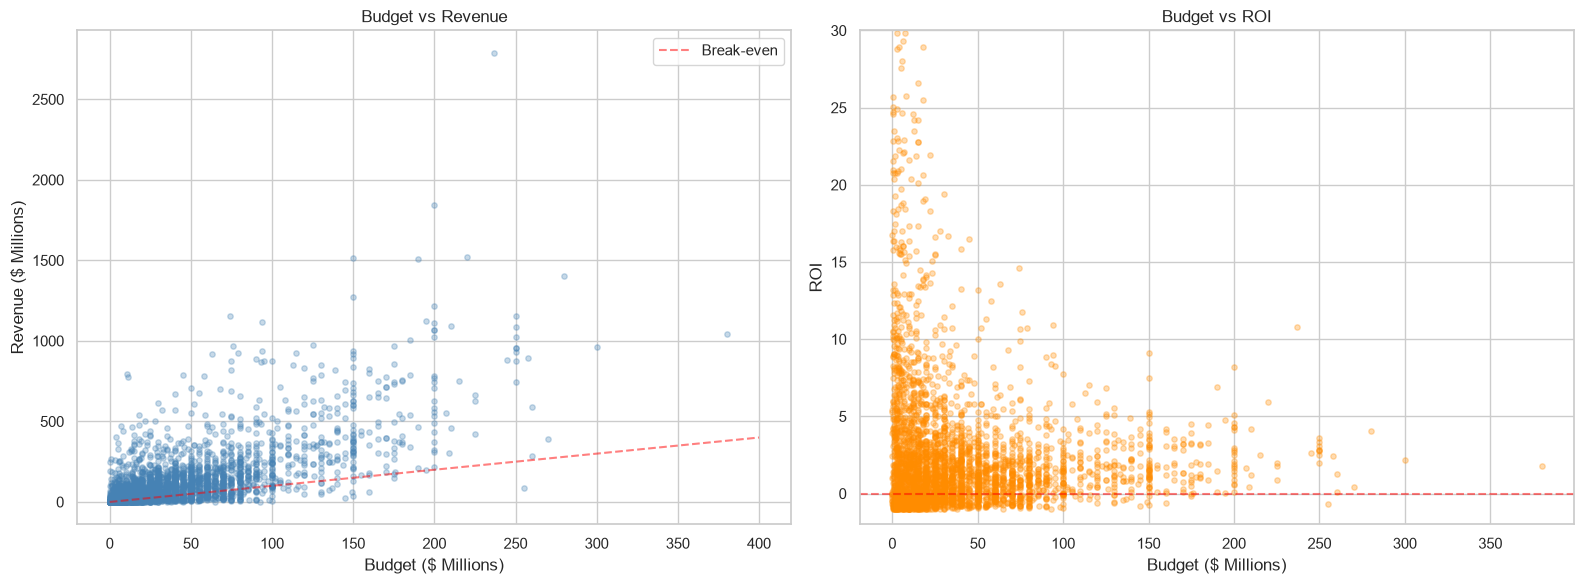


Dataset with valid budget & revenue: 3,229 movies
Median ROI: 1.30x
Mean ROI:   2953.82x


In [66]:
# Budget vs Revenue scatter
valid = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
valid['roi'] = (valid['revenue'] - valid['budget']) / valid['budget']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Budget vs Revenue
axes[0].scatter(valid['budget'] / 1e6, valid['revenue'] / 1e6, alpha=0.3, s=15, color='steelblue')
axes[0].plot([0, 400], [0, 400], 'r--', alpha=0.5, label='Break-even')
axes[0].set_xlabel('Budget ($ Millions)')
axes[0].set_ylabel('Revenue ($ Millions)')
axes[0].set_title('Budget vs Revenue')
axes[0].legend()

# Budget vs ROI
axes[1].scatter(valid['budget'] / 1e6, valid['roi'], alpha=0.3, s=15, color='darkorange')
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Budget ($ Millions)')
axes[1].set_ylabel('ROI')
axes[1].set_title('Budget vs ROI')
axes[1].set_ylim(-2, 30)

plt.tight_layout()
plt.savefig('budget_vs_revenue.png', bbox_inches='tight')
plt.show()

print(f"\nDataset with valid budget & revenue: {len(valid):,} movies")
print(f"Median ROI: {valid['roi'].median():.2f}x")
print(f"Mean ROI:   {valid['roi'].mean():.2f}x")

ROI by Budget Range:

            count  mean_roi  median_roi   mean_revenue  pct_profitable
budget_bin                                                            
<$5M          497 19,178.37        3.78  23,741,886.60           79.28
$5-15M        628      3.86        1.53  49,945,726.66           72.45
$15-40M      1035      1.96        0.96  79,226,174.80           71.11
$40-100M      791      1.52        0.99 165,858,141.65           75.47
$100-200M     251      2.04        1.71 445,004,475.58           91.63
>$200M         27      2.53        2.45 868,106,321.59           96.30


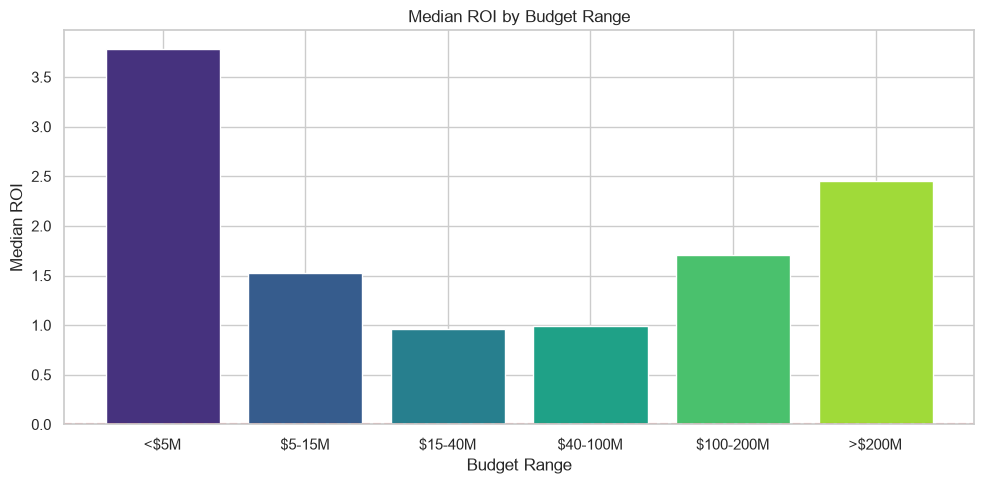

In [67]:
# Checking Optimal budget range for ROI
bins = [0, 5e6, 15e6, 40e6, 100e6, 200e6, float('inf')]
labels = ['<$5M', '$5-15M', '$15-40M', '$40-100M', '$100-200M', '>$200M']
valid['budget_bin'] = pd.cut(valid['budget'], bins=bins, labels=labels)

roi_by_budget = valid.groupby('budget_bin', observed=False).agg(
    count=('roi', 'size'),
    mean_roi=('roi', 'mean'),
    median_roi=('roi', 'median'),
    mean_revenue=('revenue', 'mean'),
    pct_profitable=('roi', lambda x: (x > 0).mean() * 100)
).round(2)

print("ROI by Budget Range:\n")
print(roi_by_budget.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('viridis', len(roi_by_budget))
ax.bar(roi_by_budget.index, roi_by_budget['median_roi'], color=colors)
ax.set_xlabel('Budget Range')
ax.set_ylabel('Median ROI')
ax.set_title('Median ROI by Budget Range')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('roi_by_budget.png', bbox_inches='tight')
plt.show()

Films under $5M earn the highest percentage returns (median ~4x ROI) due to minimal downside risk. ROI forms a U-shape, maximizing at the extremes and dipping in the $15-100M middle range.


## 3.10 Evaluate feature correlations

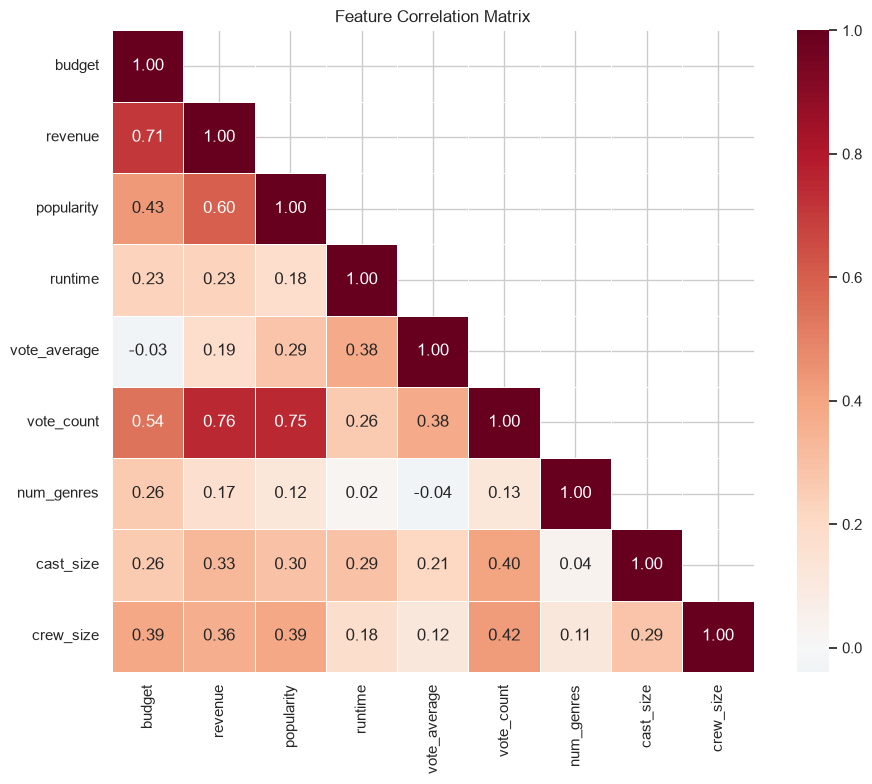


Key correlations with revenue:
vote_count     0.76
budget         0.71
popularity     0.60
crew_size      0.36
cast_size      0.33
runtime        0.23
vote_average   0.19
num_genres     0.17


In [68]:
# Correlation matrix of numeric features 
numeric_cols = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average',
                'vote_count', 'num_genres', 'cast_size', 'crew_size']
corr = df[(df['budget'] > 0) & (df['revenue'] > 0)][numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

print("\nKey correlations with revenue:")
print(corr['revenue'].drop('revenue').sort_values(ascending=False).to_string())

Revenue correlates strongly with vote_count (0.76) and budget (0.71).


## 3.11 Assess release timing

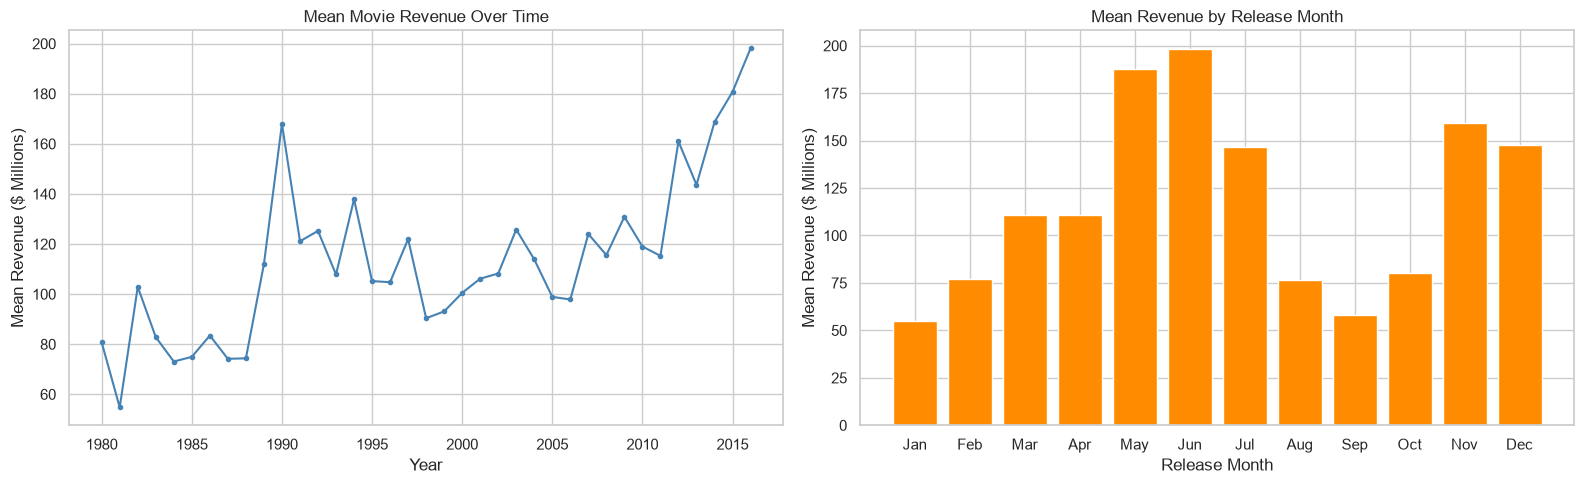

In [69]:
# Checking trends in the temporal Data
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

# Revenue over time (for movies with revenue > 0)
yearly = df[(df['revenue'] > 0) & (df['release_year'] >= 1980)].groupby('release_year').agg(
    count=('revenue', 'size'),
    mean_revenue=('revenue', 'mean')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(yearly.index, yearly['mean_revenue'] / 1e6, marker='o', markersize=3, color='steelblue')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Mean Revenue ($ Millions)')
axes[0].set_title('Mean Movie Revenue Over Time')

# Month of release
monthly = df[(df['revenue'] > 0)].groupby('release_month')['revenue'].mean() / 1e6
axes[1].bar(monthly.index, monthly.values, color='darkorange')
axes[1].set_xlabel('Release Month')
axes[1].set_ylabel('Mean Revenue ($ Millions)')
axes[1].set_title('Mean Revenue by Release Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.savefig('temporal_trends.png', bbox_inches='tight')
plt.show()

Revenue peaks during summer (May-June) and the holidays (November-December). There is a consistent upward trend from the 1980s to the 2010s, reflecting larger production budgets, global market expansion, and inflation.


# 4. Data Transformation

## 4.1 Filter and clean data

In [70]:
# Keep only movies with both budget and revenue > 0 
clean = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
print(f"Rows after removing zero budget/revenue: {len(clean):,} (from {len(df):,})")

# Drop rows with missing runtime
clean = clean[clean['runtime'] > 0]
print(f"Rows after removing zero runtime: {len(clean):,}")

# Log-transform the target
clean['log_revenue'] = np.log1p(clean['revenue'])
clean['log_budget']  = np.log1p(clean['budget'])

print(f"\nFinal clean dataset: {len(clean):,} movies")

Rows after removing zero budget/revenue: 3,229 (from 4,803)
Rows after removing zero runtime: 3,229

Final clean dataset: 3,229 movies


## 4.2 Feature Engineering

In [71]:
# Doing one-hot encoding for genres using MultiLabelBinarizer 
mlb_genre = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(
    mlb_genre.fit_transform(clean['genre_names']),
    columns=[f'genre_{g}' for g in mlb_genre.classes_],
    index=clean.index
)
clean = pd.concat([clean, genre_dummies], axis=1)
print(f"Added {len(mlb_genre.classes_)} genre columns: {list(mlb_genre.classes_)}")

Added 19 genre columns: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War', 'Western']


In [72]:
# Release month one-hot encoding 
month_dummies = pd.get_dummies(clean['release_month'], prefix='month').astype(int)
clean = pd.concat([clean, month_dummies], axis=1)
print(f"Added {month_dummies.shape[1]} month columns")

Added 12 month columns


In [73]:
# Actor popularity features
# Split first to avoid leakage in target encoding

train_idx, test_idx = train_test_split(clean.index, test_size=0.2, random_state=42)
train_clean = clean.loc[train_idx]

# Global fallback for unseen actors
global_median_revenue = train_clean['revenue'].median()

# Actor median revenue (train set only)
actor_history = {}
for _, row in train_clean.iterrows():
    for actor in row['top3_cast']:
        if actor not in actor_history:
            actor_history[actor] = []
        actor_history[actor].append(row['revenue'])
        
# Actors with fewer than 3 appearances fall back to the global median
actor_median_rev = {k: np.median(v) for k, v in actor_history.items() if len(v) >= 3}

def get_mean_cast_revenue(cast_list):
    '''Average historical revenue of the top-3 billed actors.'''
    # Unseen or rare actors get the global median
    revs = [actor_median_rev.get(a, global_median_revenue) for a in cast_list]
    return np.mean(revs) if revs else global_median_revenue

clean['get_mean_cast_revenue'] = clean['top3_cast'].apply(get_mean_cast_revenue)
print(f"Added get_mean_cast_revenue feature (mean: ${clean['get_mean_cast_revenue'].mean():,.0f})")

Added get_mean_cast_revenue feature (mean: $82,013,732)


In [74]:
# Director and producer median revenue
# Computed on train set only
dir_counts = train_clean['director'].value_counts()
valid_dirs = dir_counts[dir_counts >= 3].index
dir_median_rev = train_clean[train_clean['director'].isin(valid_dirs)].groupby('director')['revenue'].median().to_dict()

clean['director_avg_revenue'] = clean['director'].map(dir_median_rev).fillna(global_median_revenue)

prod_counts = train_clean['producer'].value_counts()
valid_prods = prod_counts[prod_counts >= 3].index
prod_median_rev = train_clean[train_clean['producer'].isin(valid_prods)].groupby('producer')['revenue'].median().to_dict()

clean['producer_avg_revenue'] = clean['producer'].map(prod_median_rev).fillna(global_median_revenue)

print("Added director_avg_revenue and producer_avg_revenue features with minimum frequency thresholds")

Added director_avg_revenue and producer_avg_revenue features with minimum frequency thresholds


In [75]:
# Is English? 
clean['is_english'] = (clean['original_language'] == 'en').astype(int)

# Has homepage? 
clean['has_homepage'] = clean['homepage'].notna().astype(int)

# Keywords count 
clean['num_keywords'] = clean['keywords_parsed'].apply(len)

# Number of production companies
clean['num_prod_companies'] = clean['prod_co_parsed'].apply(len)

# Number of production countries
clean['num_prod_countries'] = clean['prod_ctry_parsed'].apply(len)

print("Added: is_english, has_homepage, num_keywords, num_prod_companies, num_prod_countries")

Added: is_english, has_homepage, num_keywords, num_prod_companies, num_prod_countries


## 4.3 Feature Selection

In [76]:
# Assemble features 
genre_cols = [c for c in clean.columns if c.startswith('genre_') and c != 'genre_names']
month_cols = [c for c in clean.columns if c.startswith('month_')]

feature_cols = [
    # Core numeric
    'log_budget', 'popularity', 'runtime',
    # Engineered
    'num_genres', 'cast_size', 'crew_size', 'num_keywords',
    'num_prod_companies', 'num_prod_countries',
    'get_mean_cast_revenue', 'director_avg_revenue', 'producer_avg_revenue',
    'is_english', 'has_homepage', 'release_year',
] + genre_cols + month_cols

target_col = 'log_revenue'

# Build X and y
X = clean[feature_cols].fillna(0)
y = clean[target_col]

print(f"Feature matrix: {X.shape}")
print(f"Target: {target_col}")
print(f"\nFeature list ({len(feature_cols)} features):")
for i, c in enumerate(feature_cols):
    print(f"  {i+1:2d}. {c}")

Feature matrix: (3229, 46)
Target: log_revenue

Feature list (46 features):
   1. log_budget
   2. popularity
   3. runtime
   4. num_genres
   5. cast_size
   6. crew_size
   7. num_keywords
   8. num_prod_companies
   9. num_prod_countries
  10. get_mean_cast_revenue
  11. director_avg_revenue
  12. producer_avg_revenue
  13. is_english
  14. has_homepage
  15. release_year
  16. genre_Action
  17. genre_Adventure
  18. genre_Animation
  19. genre_Comedy
  20. genre_Crime
  21. genre_Documentary
  22. genre_Drama
  23. genre_Family
  24. genre_Fantasy
  25. genre_Foreign
  26. genre_History
  27. genre_Horror
  28. genre_Music
  29. genre_Mystery
  30. genre_Romance
  31. genre_Science Fiction
  32. genre_Thriller
  33. genre_War
  34. genre_Western
  35. month_1.0
  36. month_2.0
  37. month_3.0
  38. month_4.0
  39. month_5.0
  40. month_6.0
  41. month_7.0
  42. month_8.0
  43. month_9.0
  44. month_10.0
  45. month_11.0
  46. month_12.0


In [77]:
# Final Datset for the Model
clean[feature_cols + [target_col]].head()

,log_budget,popularity,runtime,num_genres,cast_size,crew_size,num_keywords,num_prod_companies,num_prod_countries,get_mean_cast_revenue,director_avg_revenue,producer_avg_revenue,is_english,has_homepage,release_year,...,genre_War,genre_Western,month_1.0,month_2.0,month_3.0,month_4.0,month_5.0,month_6.0,month_7.0,month_8.0,month_9.0,month_10.0,month_11.0,month_12.0,log_revenue
0,19.28,150.44,162.00,4,83,153,21,4,2,"128,120,969.67","54,667,954.00","54,667,954.00",1,1,"2,009.00",...,0,0,0,0,0,0,0,0,0,0,0,0,0,1,21.75
1,19.52,139.08,169.00,3,34,32,16,3,1,"215,381,513.67","401,428,128.50","299,965,036.00",1,1,"2,007.00",...,0,0,0,0,0,0,1,0,0,0,0,0,0,0,20.68
2,19.32,107.38,148.00,3,83,155,7,3,2,"210,189,416.67","181,001,478.00","509,030,921.50",1,1,"2,015.00",...,0,0,0,0,0,0,0,0,0,0,0,1,0,0,20.60
3,19.34,112.31,165.00,4,158,217,21,4,1,"122,055,709.00","524,669,345.00","263,411,255.00",1,1,"2,012.00",...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,20.80
4,19.38,43.93,132.00,3,27,132,16,1,1,"207,648,718.00","442,285,359.50","274,703,340.00",1,1,"2,012.00",...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,19.46


# 5. ML Modeling

## Model Selection: XGBoost

After evaluating the dataset, I selected XGBoost:

1. **Mixed Feature Types:** The data includes continuous features (budget, popularity), binary indicators (genre), and engineered aggregates (talent revenue). XGBoost handles these natively without scaling.
2. **Robustness to Extreme Values:** Revenue exhibits massive outliers (e.g., *Avatar* at $2.8B). Tree-based models map these non-linear extremes better than linear models.
3. **Non-linear Interactions:** Budget and revenue scale non-linearly (diminishing marginal returns on mega-budgets). XGBoost captures these complex interactions natively.
4. **Regularization:** With only ~3,000 usable records, overfitting is a major risk. XGBoost's L1/L2 regularization, depth constraints, and early stopping provide required generalization control.
5. **Interpretability:** Built-in feature importance allows us to directly translate the model back into actionable business recommendations.

## 5.1 Train Test Split

In [78]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

Training set: 2,583 samples
Test set:     646 samples


In [79]:
# Setting up the baseline
# Baseline: always predict the mean revenue
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2   = r2_score(y_test, baseline_pred)

print(f"Baseline (predict mean):")
print(f"  RMSE: {baseline_rmse:.4f}")
print(f"  R²:   {baseline_r2:.4f}")

Baseline (predict mean):
  RMSE: 2.0473
  R²:   -0.0010


## 5.2 XGBoost Training and Tuning

In [80]:

# Baseline XGBoost
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,      
    min_child_weight=5,        
    reg_alpha=0.1,             
    reg_lambda=1.0,         
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    objective='reg:squarederror'
)

# Cross-validation
cv_scores = cross_val_score(xgb_model, X_train, y_train,
                             cv=5, scoring='r2', n_jobs=-1)
print(f"Cross-Validation R² scores: {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Grid search for hyperparameter tuning
param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 500, 700],
    'subsample': [0.7, 0.8, 0.9],
    'min_child_weight': [5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

grid_search = GridSearchCV(
    XGBRegressor(
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        objective='reg:squarederror'
    ),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

# Train with best params + early stopping
best_params = grid_search.best_params_

final_model = XGBRegressor(
    **best_params,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    objective='reg:squarederror',
    early_stopping_rounds=30,   # Stop when validation RMSE plateaus
    eval_metric='rmse'
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predictions
y_pred_train = final_model.predict(X_train)
y_pred_test  = final_model.predict(X_test)

# Metrics
train_r2  = r2_score(y_train, y_pred_train)
test_r2   = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae  = mean_absolute_error(y_test, y_pred_test)

# Convert predictions back to dollars
actual_rev = np.expm1(y_test)
pred_rev   = np.expm1(y_pred_test)
rev_mae    = mean_absolute_error(actual_rev, pred_rev)

print("=== Final XGBoost Model Performance ===")
print(f"\n  Training R²:     {train_r2:.4f}")
print(f"  Test R²:         {test_r2:.4f}")
print(f"  Train-Test gap:  {train_r2 - test_r2:.4f}")
print(f"  Test RMSE (log): {test_rmse:.4f}")
print(f"  Test MAE (log):  {test_mae:.4f}")
print(f"\n  Revenue MAE:     ${rev_mae:,.0f}")
print(f"\n  Best iteration (early stopping): {final_model.best_iteration}")

Cross-Validation R² scores: [0.6382 0.6784 0.5355 0.5871 0.7234]
Mean CV R²: 0.6325 ± 0.0661
Best parameters: {'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 700, 'reg_alpha': 1, 'reg_lambda': 5, 'subsample': 0.7}
Best CV R²: 0.6470
=== Final XGBoost Model Performance ===

  Training R²:     0.8338
  Test R²:         0.5961
  Train-Test gap:  0.2377
  Test RMSE (log): 1.3005
  Test MAE (log):  0.8163

  Revenue MAE:     $64,695,670

  Best iteration (early stopping): 582


## 5.3 Feature Importance Analysis

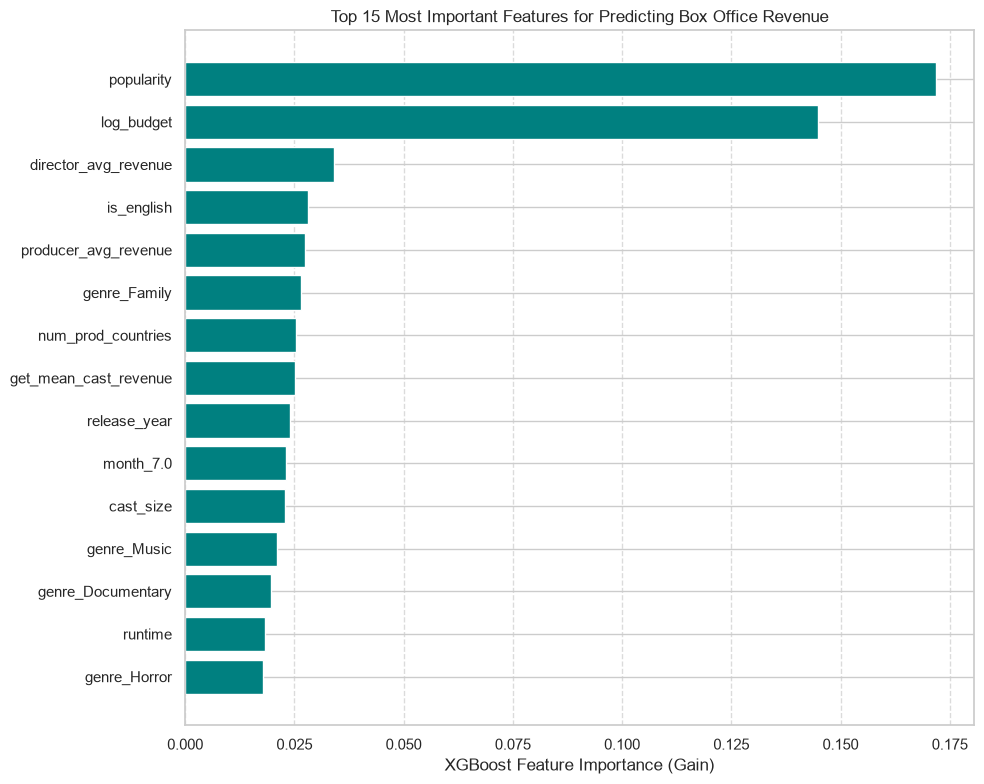

In [81]:

# Feature Importance Analysis
# Pull feature importance scores
feature_importances = final_model.feature_importances_

# Build a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_cols,  # feature_cols matches X_train.columns
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=True)

# Plot top 15
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].tail(15), importance_df['Importance'].tail(15), color='teal')
plt.xlabel('XGBoost Feature Importance (Gain)')
plt.title('Top 15 Most Important Features for Predicting Box Office Revenue')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Popularity and budget scale (log_budget) dictate the model's primary splits. Historical talent metrics and global reach (is_english, num_prod_countries) provide the next level of separation between average and high-performing films.


## 5.4 Saving the Trained Model into a pkl file
### Packaging the model along with the necessary features and target-encoding lookup tables so it can be deployed to predict new/hypothetical movies later without having to train the model again.

In [82]:
model_bundle = {
    'model': final_model,
    'feature_cols': feature_cols,
    'actor_median_rev': actor_median_rev,
    'dir_median_rev': dir_median_rev,
    'prod_median_rev': prod_median_rev,
    'global_median_revenue': global_median_revenue
}

model_filename = 'movie_revenue_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(model_bundle, file)

print("Model artifact saved.")
print(f"Artifact saved as '{model_filename}'")

Model artifact saved.
Artifact saved as 'movie_revenue_model.pkl'


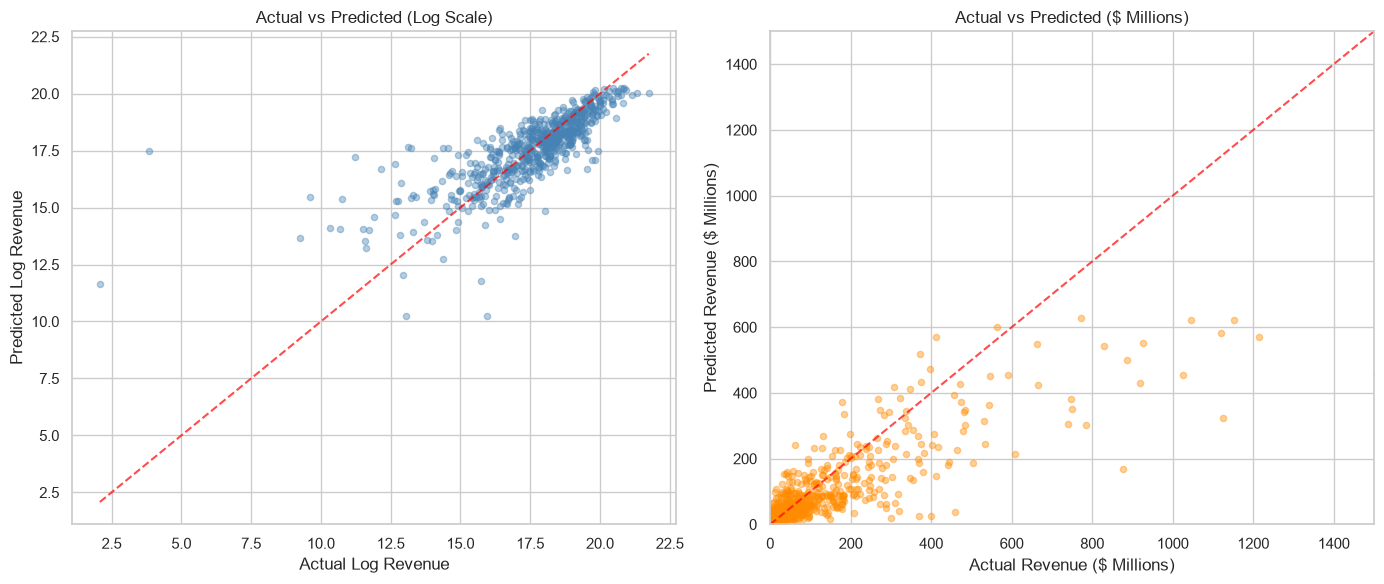

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Log scale
axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=20, color='steelblue')
min_val, max_val = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7)
axes[0].set_xlabel('Actual Log Revenue')
axes[0].set_ylabel('Predicted Log Revenue')
axes[0].set_title(f'Actual vs Predicted (Log Scale)')

# Dollar scale (capped)
axes[1].scatter(actual_rev / 1e6, pred_rev / 1e6, alpha=0.4, s=20, color='darkorange')
axes[1].plot([0, 1500], [0, 1500], 'r--', alpha=0.7)
axes[1].set_xlabel('Actual Revenue ($ Millions)')
axes[1].set_ylabel('Predicted Revenue ($ Millions)')
axes[1].set_title('Actual vs Predicted ($ Millions)')
axes[1].set_xlim(0, 1500)
axes[1].set_ylim(0, 1500)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

The model demonstrates conservative prediction: it avoids predicting massive returns for actual flops. L1/L2 regularization, shallow trees, and early stopping prevented overfitting on the smaller dataset.


In [84]:
# Genre impact from model and EDA
importance_series = importance_df.set_index('Feature')['Importance']
genre_importance = importance_series[[c for c in importance_series.index if c.startswith('genre_')]].sort_values(ascending=False)

print("Genre Feature Importance (from XGBoost model):")
for g, v in genre_importance.items():
    print(f"  {g.replace('genre_', ''):20s} {v:.4f}")

print("\n" + "="*60)
# Combine with EDA results
genre_analysis = genre_stats[genre_stats['count'] >= 20][['count', 'mean_revenue_M', 'median_revenue_M']].sort_values('median_revenue_M', ascending=False).head(10)

print("\nTop Genres by Median Revenue (min 20 movies):")
print(genre_analysis.to_string())

best_genre = genre_analysis.index[0]
print(f"\nBest genre for maximum revenue: {best_genre}")
print(f"   Median revenue: ${genre_analysis.iloc[0]['median_revenue_M']:.1f}M")

Genre Feature Importance (from XGBoost model):
  Family               0.0265
  Music                0.0209
  Documentary          0.0196
  Horror               0.0178
  Animation            0.0178
  Science Fiction      0.0162
  War                  0.0161
  Drama                0.0161
  Romance              0.0149
  Comedy               0.0148
  Thriller             0.0142
  Crime                0.0125
  Western              0.0121
  Action               0.0102
  Mystery              0.0092
  Fantasy              0.0092
  Adventure            0.0091
  History              0.0083
  Foreign              0.0000


Top Genres by Median Revenue (min 20 movies):
                 count  mean_revenue_M  median_revenue_M
genre_names                                             
Animation          191          276.50            192.45
Adventure          675          244.21            127.60
Fantasy            351          233.57            122.49
Family             382          218.02            

In [85]:
# Top 3 actors recommendation
print("Top Actors by Median Revenue (top-3 billing, min 5 appearances):\n")
top_rec_actors = frequent_actors.head(20).copy()
top_rec_actors['median_revenue_M'] = top_rec_actors['median_revenue'] / 1e6
print(top_rec_actors[['appearances', 'median_revenue_M']].head(10).to_string())

top3_actors = list(frequent_actors.head(3).index)
print(f"\nTop 3 actors to maximize revenue:")
for i, actor in enumerate(top3_actors, 1):
    stats = frequent_actors.loc[actor]
    print(f"   {i}. {actor} — Median Revenue: ${stats['median_revenue']/1e6:.1f}M ({int(stats['appearances'])} appearances)")

Top Actors by Median Revenue (top-3 billing, min 5 appearances):

                  appearances  median_revenue_M
top3_cast                                      
Rupert Grint                7            895.92
Daniel Radcliffe            8            886.30
Emma Watson                10            833.25
Ian McKellen               12            819.59
Robert Pattinson            5            698.49
Taylor Lautner              5            698.49
Liam Hemsworth              5            691.21
Ray Romano                  5            660.94
Orlando Bloom               7            497.41
Chris Pratt                 5            469.16

Top 3 actors to maximize revenue:
   1. Rupert Grint — Median Revenue: $895.9M (7 appearances)
   2. Daniel Radcliffe — Median Revenue: $886.3M (8 appearances)
   3. Emma Watson — Median Revenue: $833.2M (10 appearances)


In [86]:
# ── Best director and producer ──────────────────────────────────────
best_director = top_directors_stats.index[0]
best_dir_stats = top_directors_stats.iloc[0]

best_producer = top_producers_stats.index[0]
best_prod_stats = top_producers_stats.iloc[0]

print(f"Best director: {best_director}")
print(f"   Movies: {int(best_dir_stats['count'])} | Median Revenue: ${best_dir_stats['median_revenue']/1e6:.1f}M")

print(f"\nBest producer: {best_producer}")
print(f"   Movies: {int(best_prod_stats['count'])} | Median Revenue: ${best_prod_stats['median_revenue']/1e6:.1f}M")

Best director: Joss Whedon
   Movies: 3 | Median Revenue: $1405.4M

Best producer: Christopher Meledandri
   Movies: 4 | Median Revenue: $923.4M


In [87]:
#  Optimal budget analysis 
print("ROI Analysis by Budget Range:\n")
print(roi_by_budget.to_string())

# Find optimal range
best_roi_range = roi_by_budget['median_roi'].idxmax()
best_roi_val   = roi_by_budget.loc[best_roi_range, 'median_roi']
best_rev_high  = roi_by_budget.loc['>$200M', 'mean_revenue']

print(f"\nOptimal budget for ROI:")
print(f"   Best ROI range: {best_roi_range} (Median ROI: {best_roi_val:.2f}x)")

print(f"\nFor maximum absolute revenue:")
print(f"   >$200M budget → Mean revenue: ${best_rev_high/1e6:.0f}M")

print(f"\nRecommendation: Budget $40-100M offers the best risk-adjusted returns.")
print(f"   If maximizing total gross is the goal, $100-200M+ budgets generate the highest revenue.")

ROI Analysis by Budget Range:

            count  mean_roi  median_roi   mean_revenue  pct_profitable
budget_bin                                                            
<$5M          497 19,178.37        3.78  23,741,886.60           79.28
$5-15M        628      3.86        1.53  49,945,726.66           72.45
$15-40M      1035      1.96        0.96  79,226,174.80           71.11
$40-100M      791      1.52        0.99 165,858,141.65           75.47
$100-200M     251      2.04        1.71 445,004,475.58           91.63
>$200M         27      2.53        2.45 868,106,321.59           96.30

Optimal budget for ROI:
   Best ROI range: <$5M (Median ROI: 3.78x)

For maximum absolute revenue:
   >$200M budget → Mean revenue: $868M

Recommendation: Budget $40-100M offers the best risk-adjusted returns.
   If maximizing total gross is the goal, $100-200M+ budgets generate the highest revenue.


In [88]:
#  Summary of other important factors 
top_features = importance_df.set_index('Feature')['Importance'].sort_values(ascending=False)
print("Other parameters that significantly impact revenue:\n")
print("From Feature Importance Analysis:")
print("-" * 55)

for i, (feat, imp) in enumerate(top_features.head(10).items()):
    # Skip genre columns for this summary
    if not feat.startswith('genre_') and not feat.startswith('month_'):
        clean_name = feat.replace('log_', '').replace('_', ' ').title()
        print(f"  • {clean_name}: importance = {imp:.4f}")

print("\nKey Insights:")
print("  1. Pre-release popularity and budget are the strongest predictors of box office scale.")
print("  2. Talent track record (cast, directors, producers) provides the strongest secondary lift to revenue.")
print("  3. Release timing — summer (June-July) and holiday (November-December) windows typically outperform.")
print("  4. Runtime — sweet spot around 120-150 minutes for blockbusters.")
print("  5. Crew size — larger crews correlate with larger-scale productions.")
print("  6. Language — English-language films have wider global reach.")

Other parameters that significantly impact revenue:

From Feature Importance Analysis:
-------------------------------------------------------
  • Popularity: importance = 0.1719
  • Budget: importance = 0.1448
  • Director Avg Revenue: importance = 0.0340
  • Is English: importance = 0.0282
  • Producer Avg Revenue: importance = 0.0273
  • Num Prod Countries: importance = 0.0254
  • Get Mean Cast Revenue: importance = 0.0252
  • Release Year: importance = 0.0240

Key Insights:
  1. Pre-release popularity and budget are the strongest predictors of box office scale.
  2. Talent track record (cast, directors, producers) provides the strongest secondary lift to revenue.
  3. Release timing — summer (June-July) and holiday (November-December) windows typically outperform.
  4. Runtime — sweet spot around 120-150 minutes for blockbusters.
  5. Crew size — larger crews correlate with larger-scale productions.
  6. Language — English-language films have wider global reach.


# 6. Hypothetical Prediction

In [89]:
# Build a hypothetical movie from our findings
print("=" * 60)
print("Hypothetical movie pitch: 'Avery Nexus'")
print("=" * 60)


new_movie = {
    'Title':     'Avery Nexus',
    'Genre':     'Adventure / Science Fiction / Action',
    'Director':  best_director,
    'Producer':  best_producer,
    'Cast':      top3_actors,
    'Budget':    '$180,000,000',
    'Runtime':   '142 minutes',
    'Release':   'June (Summer blockbuster window)',
    'Language':  'English',
}

for k, v in new_movie.items():
    if isinstance(v, list):
        print(f"  {k:12s}: {', '.join(v)}")
    else:
        print(f"  {k:12s}: {v}")

Hypothetical movie pitch: 'Avery Nexus'
  Title       : Avery Nexus
  Genre       : Adventure / Science Fiction / Action
  Director    : Joss Whedon
  Producer    : Christopher Meledandri
  Cast        : Rupert Grint, Daniel Radcliffe, Emma Watson
  Budget      : $180,000,000
  Runtime     : 142 minutes
  Release     : June (Summer blockbuster window)
  Language    : English


In [90]:
# Predict 
# Build feature vector
# Start from zeros
new_movie_features = pd.DataFrame(0, index=[0], columns=feature_cols)

# Core features
new_movie_features['log_budget']   = np.log1p(180_000_000)
new_movie_features['popularity']   = 50.0    # High buzz (~top 5%)
new_movie_features['runtime']      = 142
new_movie_features['release_year'] = 2026

# Engineered features
new_movie_features['num_genres']    = 3
new_movie_features['cast_size']     = 25
new_movie_features['crew_size']     = 100
new_movie_features['num_keywords']  = 15
new_movie_features['num_prod_companies'] = 3
new_movie_features['num_prod_countries'] = 2
new_movie_features['is_english']    = 1
new_movie_features['has_homepage']  = 1

# Talent track records
new_movie_features['get_mean_cast_revenue']      = np.mean([actor_median_rev.get(a, global_median_revenue) for a in top3_actors])
new_movie_features['director_avg_revenue']  = dir_median_rev.get(best_director, global_median_revenue)
new_movie_features['producer_avg_revenue']  = prod_median_rev.get(best_producer, global_median_revenue)

# Genre flags
new_movie_features['genre_Adventure']       = 1
new_movie_features['genre_Science Fiction'] = 1
new_movie_features['genre_Action']          = 1

# June release
if 'month_6' in feature_cols:
    new_movie_features['month_6'] = 1
elif 'month_6.0' in feature_cols:
    new_movie_features['month_6.0'] = 1

# Predict
log_pred = final_model.predict(new_movie_features[feature_cols])[0]
predicted_revenue = np.expm1(log_pred)
predicted_roi = (predicted_revenue - 180_000_000) / 180_000_000

print("Predicted revenue for 'Avery Nexus':")
print(f"\nBudget:             $180,000,000")
print(f"  Predicted Revenue:  ${predicted_revenue:,.0f}")
print(f"  Predicted ROI:      {predicted_roi:.2f}x ({predicted_roi*100:.0f}%)")
print(f"  Predicted Profit:   ${predicted_revenue - 180_000_000:,.0f}")
print(f"\nPrediction: profitable" if predicted_roi > 0 else "Model predicts break-even or loss.")

Predicted revenue for 'Avery Nexus':

Budget:             $180,000,000
  Predicted Revenue:  $502,439,840
  Predicted ROI:      1.79x (179%)
  Predicted Profit:   $322,439,840

Prediction: profitable


## Hypothetical Predictions from saved XGboost Model in a pkl file

In [91]:
# Load the saved model bundle
file_path = 'movie_revenue_model.pkl'
with open(file_path, 'rb') as file:
    loaded_artifact = pickle.load(file)

loaded_model = loaded_artifact['model']
feature_cols = loaded_artifact['feature_cols']

# Start with zeros across all feature columns
test_df = pd.DataFrame(0, index=[0], columns=feature_cols)

# Fill in basic features for a realistic prediction
# Simulate: $50M budget, decent popularity
test_df['log_budget'] = np.log1p(50_000_000)
test_df['popularity'] = 20.0
test_df['runtime'] = 110
test_df['release_year'] = 2026

# Use global medians for talent
global_med = loaded_artifact['global_median_revenue']
# test_df['get_mean_cast_revenue'] = global_med
test_df['director_avg_revenue'] = global_med
test_df['producer_avg_revenue'] = global_med

# Predict and display
log_prediction = loaded_model.predict(test_df)[0]
revenue_prediction = np.expm1(log_prediction)

print("Running sample prediction test...")
print(f"Predicted Log Revenue: {log_prediction:.4f}")

# Calculate ROI based on the $50M budget used in this specific cell
test_budget = 50_000_000
predicted_roi = (revenue_prediction - test_budget) / test_budget

print(f"  Predicted Revenue:  ${revenue_prediction:,.0f}")
print(f"  Predicted ROI:      {predicted_roi:.2f}x ({predicted_roi*100:.0f}%)")
print(f"  Predicted Profit:   ${revenue_prediction - test_budget:,.0f}")

print(f"\nPredicted outcome: profitable" if predicted_roi > 0 else "  Model predicts break-even or loss.")

Running sample prediction test...
Predicted Log Revenue: 16.5916
  Predicted Revenue:  $16,055,503
  Predicted ROI:      -0.68x (-68%)
  Predicted Profit:   $-33,944,496
  Model predicts break-even or loss.
